# Constants

In [70]:
import os

DATA_DIR = os.path.join(os.getcwd(), "data", "physionet.org", "files", "eegmmidb", "1.0.0")
print(DATA_DIR)
# "/content/drive/MyDrive/physionet.org/files/eegmmidb/1.0.0/"
DATA_URL = "https://physionet.org/files/eegmmidb/1.0.0"

N_SUBJECTS = 30 # 109

DATA_EX_RUNS = [3, 7, 11]
DATA_IM_RUNS = [4, 8, 12]
DATA_RUNS = [*DATA_EX_RUNS, *DATA_IM_RUNS]

SELECTED_NODES = ["C1", "C2", "C3", "C4", "C5", "C6", "Cz"]

# for our runs, according to https://physionet.org/content/eegmmidb/1.0.0/
# T1 means left fist, T2 means right fist. just in case, const below
LEFT_ANNO = "T1"
RIGHT_ANNO = "T2"
NONE_ANNO = "T0"

DELTA_BAND = (0.5, 4)          # Deep sleep, very slow brain activity
THETA_BAND = (4, 8)            # Drowsiness, memory, some cognitive processes
ALPHA_BAND = MU_BAND = (8, 13) # Relaxed wakefulness, especially eyes closed
                               # Sensorimotor rhythm; closely related to motor activity
BETA_BAND = (13, 30)           # Active thinking, motor activity
GAMMA_BAND = (30, 9999999)     # Higher-frequency neural activity, perception/cognition

BANDS = [DELTA_BAND, THETA_BAND, ALPHA_BAND, BETA_BAND, GAMMA_BAND]

/Users/jeffrey/UCB/26-27/NeurotechATB/NTatB_FA2026/data/physionet.org/files/eegmmidb/1.0.0


# Download Utilities
Just a couple download-related utility methods. This way, we can more quickly just download stuff if needed.

In [13]:
import os

def format_subject(subject):
  return f"S{subject:03d}"

def get_filename(subject, run):
  return f"{format_subject(subject)}R{run:02d}.edf"

def get_filepath(subject, run=None):
  subject_f = format_subject(subject)
  if run is None:
    return os.path.join(DATA_DIR, subject_f)
  return os.path.join(DATA_DIR, subject_f, get_filename(subject, run))

def get_url(subject, run):
  return f"{DATA_URL}/{format_subject(subject)}/{get_filename(subject, run)}"

In [6]:
import shutil

# UNCOMMENT IF YOU DARE! DO NOT RUN ALL IF SO!
# shutil.rmtree(DATA_DIR)

# Data Downloading
Instead of manually uploading data to Drive to read later, we can also handle the downloading, so that we _only get the runs we want_. The rest of the runs, the annotation data, and `index.html`s are not necessary. We can handle that data management.

In [9]:
%pip install requests

You should consider upgrading via the '/Users/jeffrey/UCB/26-27/NeurotechATB/NTatB_FA2026/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [71]:
import os
import shutil
import requests

# only dl what we need! who needs the rest

os.makedirs(DATA_DIR, exist_ok=True)
subjects = []

for subject in range(1, N_SUBJECTS+1):
    os.makedirs(get_filepath(subject), exist_ok=True)
    subjects.append(format_subject(subject))

    for run in DATA_RUNS:
        url = get_url(subject, run)
        filepath = get_filepath(subject, run)
        filename = os.path.basename(filepath)

        if os.path.exists(filepath):
            print(f"Already downloaded: {filename}")
            continue

        print(f"Downloading {filename}...")

        with requests.get(url, stream=True) as response:
            response.raise_for_status()

            with open(filepath, "wb") as f:
                for chunk in response.iter_content(chunk_size=1024 * 1024):
                    f.write(chunk)

# clean up stuff so that if this script is terminated prematurely,
# other partial junk gets cleared up

for possible_subject in os.listdir(DATA_DIR):
  if possible_subject in subjects:
    fileset = [get_filename(int(possible_subject[1:]), run) for run in DATA_RUNS]
    for file in os.listdir(os.path.join(DATA_DIR, possible_subject)):
      if file not in fileset:
        print(f"Removing {file} from {possible_subject}...")
        os.remove(os.path.join(DATA_DIR, possible_subject, file))
    continue
#   print(f"Removing {possible_subject}...")
#   shutil.rmtree(os.path.join(DATA_DIR, possible_subject))

Already downloaded: S001R03.edf
Already downloaded: S001R07.edf
Already downloaded: S001R11.edf
Already downloaded: S001R04.edf
Already downloaded: S001R08.edf
Already downloaded: S001R12.edf
Already downloaded: S002R03.edf
Already downloaded: S002R07.edf
Already downloaded: S002R11.edf
Already downloaded: S002R04.edf
Already downloaded: S002R08.edf
Already downloaded: S002R12.edf
Already downloaded: S003R03.edf
Already downloaded: S003R07.edf
Already downloaded: S003R11.edf
Already downloaded: S003R04.edf
Already downloaded: S003R08.edf
Already downloaded: S003R12.edf
Already downloaded: S004R03.edf
Already downloaded: S004R07.edf
Already downloaded: S004R11.edf
Already downloaded: S004R04.edf
Already downloaded: S004R08.edf
Already downloaded: S004R12.edf
Already downloaded: S005R03.edf
Already downloaded: S005R07.edf
Already downloaded: S005R11.edf
Already downloaded: S005R04.edf
Already downloaded: S005R08.edf
Already downloaded: S005R12.edf
Already downloaded: S006R03.edf
Already 

# Data Loading
We'll use MNE. Pretty basic stuff, NP in the backend, so everything just works™.

In [19]:
%pip install mne

     |████████████████████████████████| 7.5 MB 3.1 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 23.8 MB/s eta 0:00:01
     |████████████████████████████████| 67 kB 14.0 MB/s eta 0:00:01
     |████████████████████████████████| 22.4 MB 49.4 MB/s eta 0:00:01
     |████████████████████████████████| 8.2 MB 14.3 MB/s eta 0:00:01
     |████████████████████████████████| 134 kB 28.3 MB/s eta 0:00:01
     |████████████████████████████████| 80 kB 26.0 MB/s eta 0:00:011
     |████████████████████████████████| 253 kB 44.9 MB/s eta 0:00:01
     |████████████████████████████████| 3.1 MB 82.3 MB/s eta 0:00:01
     |████████████████████████████████| 4.8 MB 21.2 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 10.7 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 30.0 MB/s eta 0:00:01
You should consider upgrading via the '/Users/jeffrey/UCB/26-27/NeurotechATB/NTatB_FA2026/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restar

In [20]:
import mne

def load(subject, run, *, preload):
  path = get_filepath(subject, run)
  raw = mne.io.read_raw_edf(path, preload=preload)
  # weirdly formatted channel names that have periods
  # to keep consistent column width, just get rid of those
  raw.rename_channels(lambda name: name.replace(".", ""))
  return raw

## Data Loading Testing
The stuff below is just to test our data loading, to see if we're actually extracting meaningful data.

In [21]:
raw = load(1, DATA_EX_RUNS[0], preload=False)

Extracting EDF parameters from /Users/jeffrey/UCB/26-27/NeurotechATB/NTatB_FA2026/data/physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...


Using matplotlib as 2D backend.


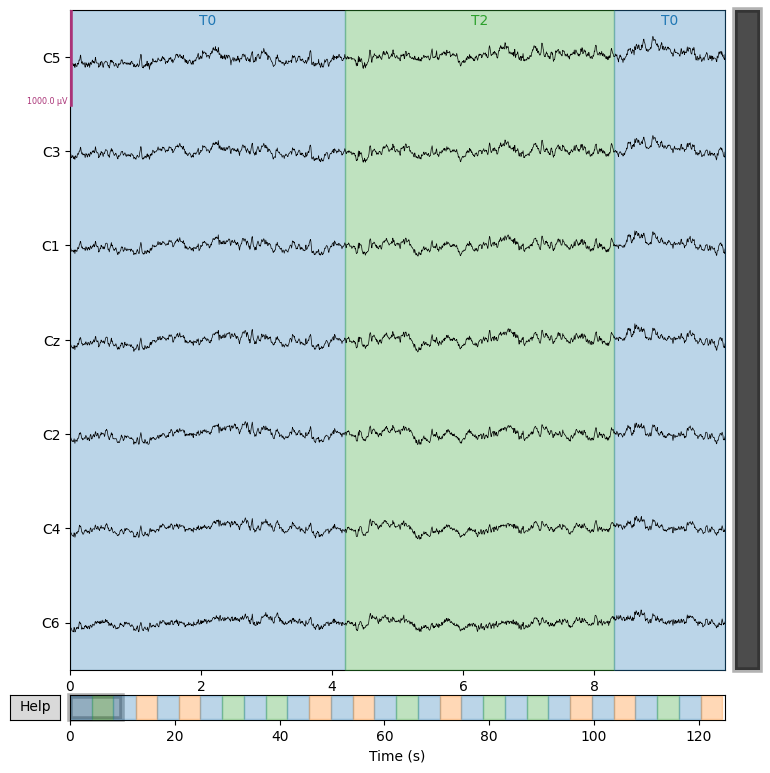

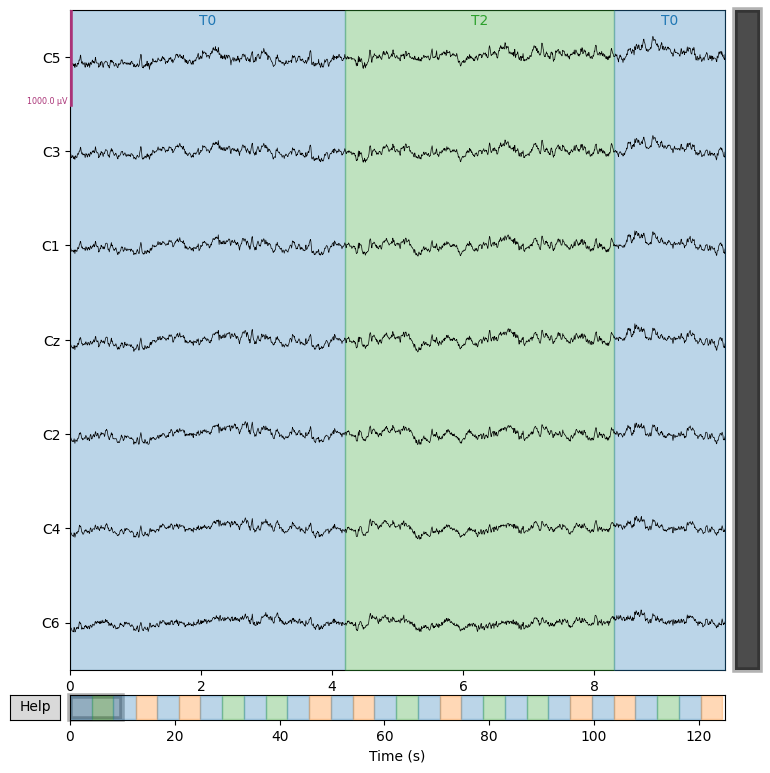

In [22]:
raw.plot(
    picks=SELECTED_NODES,
    scalings=5e-4)

In [23]:
for onset, duration, description in zip(
    raw.annotations.onset,
    raw.annotations.duration,
    raw.annotations.description):
    print(f"{description}: @ {onset:.2f}s for {duration:.2f}s")

T0: @ 0.00s for 4.20s
T2: @ 4.20s for 4.10s
T0: @ 8.30s for 4.20s
T1: @ 12.50s for 4.10s
T0: @ 16.60s for 4.20s
T1: @ 20.80s for 4.10s
T0: @ 24.90s for 4.20s
T2: @ 29.10s for 4.10s
T0: @ 33.20s for 4.20s
T2: @ 37.40s for 4.10s
T0: @ 41.50s for 4.20s
T1: @ 45.70s for 4.10s
T0: @ 49.80s for 4.20s
T1: @ 54.00s for 4.10s
T0: @ 58.10s for 4.20s
T2: @ 62.30s for 4.10s
T0: @ 66.40s for 4.20s
T1: @ 70.60s for 4.10s
T0: @ 74.70s for 4.20s
T2: @ 78.90s for 4.10s
T0: @ 83.00s for 4.20s
T2: @ 87.20s for 4.10s
T0: @ 91.30s for 4.20s
T1: @ 95.50s for 4.10s
T0: @ 99.60s for 4.20s
T1: @ 103.80s for 4.10s
T0: @ 107.90s for 4.20s
T2: @ 112.10s for 4.10s
T0: @ 116.20s for 4.20s
T1: @ 120.40s for 4.10s


In [24]:
print(raw.info["sfreq"])

160.0


# Single-Run Data Utilities
This stuff is just so we can more easily get sample data from a single run. Of course, we need the `raw` MNE object as input.

In [25]:
def get_data_by_ts(raw, channels, start_ts, stop_ts):
  data = raw.copy() \
    .crop(
        tmin=start_ts,
        tmax=min(stop_ts, raw.times[-1])) \
    .get_data(picks=channels)
  return data

def get_datas_by_tag(raw, channels, tag, *, padding_s=0):
  datas = []
  for onset, duration, description in zip(
    raw.annotations.onset,
    raw.annotations.duration,
    raw.annotations.description):
    if description != tag:
      continue
    onset += padding_s
    duration -= padding_s * 2
    if duration <= 0:
      continue
    datas.append(get_data_by_ts(raw, channels, onset, onset+duration))
  return datas

# Multi-Run Data Utilities
This stuff is to handle multiple runs. We build a general data bank schema, and then create a filter/select function to get all the trials we want. Each "trial" here is one annotated section, marked T0/1/2 on one run. We store them in this flat manner to more easily filter/select.

As a side note, I experimented with adding some time padding since we know that the subject won't _instantly_ think "move left fist" or "move right fist." However, it seemed to make accuracy worse. I need to investigate why.

In [100]:
DATA_PADDING = 0
# schema: (subject: int, run: int, anno: str, datas: list[data])
DATA = []
for subject in range(1, N_SUBJECTS+1):
  for run in DATA_RUNS:
    print(f"Loading {get_filename(subject, run)}...")
    raw = load(subject, run, preload=True)
    DATA.append((subject, run, LEFT_ANNO, get_datas_by_tag(raw, SELECTED_NODES, LEFT_ANNO, padding_s=DATA_PADDING)))
    DATA.append((subject, run, RIGHT_ANNO, get_datas_by_tag(raw, SELECTED_NODES, RIGHT_ANNO, padding_s=DATA_PADDING)))
    DATA.append((subject, run, NONE_ANNO, get_datas_by_tag(raw, SELECTED_NODES, NONE_ANNO, padding_s=DATA_PADDING)))

Loading S001R03.edf...
Extracting EDF parameters from /Users/jeffrey/UCB/26-27/NeurotechATB/NTatB_FA2026/data/physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Loading S001R07.edf...
Extracting EDF parameters from /Users/jeffrey/UCB/26-27/NeurotechATB/NTatB_FA2026/data/physionet.org/files/eegmmidb/1.0.0/S001/S001R07.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Loading S001R11.edf...
Extracting EDF parameters from /Users/jeffrey/UCB/26-27/NeurotechATB/NTatB_FA2026/data/physionet.org/files/eegmmidb/1.0.0/S001/S001R11.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Loading S001R04.edf...
Extracting EDF parameters from /Users/jeffrey/UCB/26-27/NeurotechATB/NTatB_FA2026/data/physionet.org/files/eegmmidb/1.0

In [101]:
def allowed(val, valset):
  if valset is None:
    return True
  if not isinstance(valset, list):
    return allowed(val, [valset])
  return val in valset

def get_trials(*, qsubject=None, qrun=None, qrun_type=None, qside=None):
  trials = []
  for (subject, run, anno, datas) in DATA:
    run_type = "EX" if run in DATA_EX_RUNS else "IM"
    side = "L" if anno == LEFT_ANNO else ("R" if anno == RIGHT_ANNO else "N")
    if not allowed(subject, qsubject):
      continue
    if not allowed(run, qrun):
      continue
    if not allowed(run_type, qrun_type):
      continue
    if not allowed(side, qside):
      continue
    trials.extend(datas)
  return trials

Just testing code below, please ignore!

In [28]:
trials = get_trials(qrun_type="EX", qside="L")
print(len(trials))
print(trials[0].shape)

682
(7, 657)


Generalized data bins, to reduce duplicate processing.

In [102]:
trials_EX_L = get_trials(qrun_type="EX", qside="L")
trials_EX_R = get_trials(qrun_type="EX", qside="R")
trials_EX_N = get_trials(qrun_type="EX", qside="N")
trials_IM_L = get_trials(qrun_type="IM", qside="L")
trials_IM_R = get_trials(qrun_type="IM", qside="R")
trials_IM_N = get_trials(qrun_type="IM", qside="N")

print(len(trials_EX_L))
print(len(trials_EX_R))
print(len(trials_EX_N))
print(len(trials_IM_L))
print(len(trials_IM_R))
print(len(trials_IM_N))

682
668
1350
683
667
1350


# LDA Model Fitting
These are just basic tools to fit a linear classifier to data. We have manual train/test selection for testing EX→IM generalization, and an auto train/test selection just for general training.

In [33]:
%pip install scipy
%pip install scikit-learn

You should consider upgrading via the '/Users/jeffrey/UCB/26-27/NeurotechATB/NTatB_FA2026/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/jeffrey/UCB/26-27/NeurotechATB/NTatB_FA2026/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [104]:
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

def lda_test(model, X_test, y_test):
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  conf_mat = confusion_matrix(y_test, y_pred)
  return accuracy, conf_mat

def lda_train_manu(X_train, X_test, y_train, y_test, *, v=False):
  if v:
    print(f"LDA: train manu")
    print(f"LDA: -> ntrain = {X_train.shape[0]}")
    print(f"LDA: -> ntest  = {X_test.shape[0]}")

  model = LinearDiscriminantAnalysis()
  model.fit(X_train, y_train)

  return lda_test(model, X_test, y_test) + (model,)

def lda_train_auto(X, y, *, test=0.2, v=False):
  if v:
    print(f"LDA: train auto")
    print(f"LDA: -> n = {X.shape[0]}")
  X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test,
    random_state=42,
    stratify=y)
  return lda_train_manu(X_train, X_test, y_train, y_test)

def print_train_result(pred, given, typ, results):
  accuracy, conf_mat, model = results
  print("+" + "-" * 50)
  print(f"| TRAINING ({typ}) pred={pred} given={given} RESULTS:")
  print(f"| -> accuracy = {accuracy:.04f}")
  print(f"| -> conf_mat = {conf_mat[0, 0]} {conf_mat[0, 1]}")
  print(f"|               {conf_mat[1, 0]} {conf_mat[1, 1]}")
  print("+" + "-" * 50)
  return results

def print_test_result(pred, given, typ, results):
  accuracy, conf_mat = results
  print("+" + "-" * 50)
  print(f"| TESTING ({typ}) pred={pred} given={given} RESULTS:")
  print(f"| -> accuracy = {accuracy:.04f}")
  print(f"| -> conf_mat = {conf_mat[0, 0]} {conf_mat[0, 1]}")
  print(f"|               {conf_mat[1, 0]} {conf_mat[1, 1]}")
  print("+" + "-" * 50)

# Spectral Features Linear Model
This is basic code to try to fit a linear model/classifier to spectral information. We split the raw signals into bins of frequency power and integrate to get the "power" in each bin aka. special type of brain wave.

I tested just C3/C4/Cz but it had a lower accuracy than C1/2/3/4/5/6/z. I need to investigate why. I also tested multiple combinations of included bins/bands, with mu+beta always included while theta/gamma were optional, just to see the difference between different waves. Counterintuitively, including all the bands lowered accuracy.

In [105]:
import numpy as np
from scipy.signal import welch

SFLM_CHANNELS = ["C1", "C2", "C3", "C4", "C5", "C6", "Cz"]

def sflm_extract_power(freqs, psd, start_hz, stop_hz):
  mask = (freqs >= start_hz) & (freqs <= stop_hz)
  power = np.trapezoid(psd[mask], freqs[mask])
  return power

def sflm_analyze_signal(bands, signal):
  freqs, psd = welch(signal, fs=160)
  return [sflm_extract_power(freqs, psd, start, stop) for start, stop in bands]

def sflm_analyze_trial(bands, trial):
  powers = []
  for channel in SFLM_CHANNELS:
    powers.extend(sflm_analyze_signal(bands, trial[SELECTED_NODES.index(channel), :]))
  return powers

def sflm_analyze_trials(bands, trials):
  return [sflm_analyze_trial(bands, trial) for trial in trials]

In [ ]:
def format_bands(bands):
  return "+".join([["d", "t", "a/m", "b", "g"][BANDS.index(band)] for band in bands])

SFLM_BANDS_SET = [
    [MU_BAND, BETA_BAND],
    [THETA_BAND, MU_BAND, BETA_BAND],
    [MU_BAND, BETA_BAND, GAMMA_BAND],
    [THETA_BAND, MU_BAND, BETA_BAND, GAMMA_BAND],
]

SFLM_INCLUDE_N = False

SFLM_TRAIN_DATA = []
SFLM_MODELS = []

powers_L = get_trials(qside="L")
powers_R = get_trials(qside="R")
classes = np.array(["L"] * len(powers_L) + ["R"] * len(powers_R))
powers_no1_L = get_trials(qsubject=list(range(2, N_SUBJECTS + 1)), qside="L")
powers_no1_R = get_trials(qsubject=list(range(2, N_SUBJECTS + 1)), qside="R")
classes_no1 = np.array(["L"] * len(powers_no1_L) + ["R"] * len(powers_no1_R))
powers_1_L = get_trials(qsubject=1, qside="L")
powers_1_R = get_trials(qsubject=1, qside="R")
classes_1 = np.array(["L"] * len(powers_1_L) + ["R"] * len(powers_1_R))

for bands in SFLM_BANDS_SET:
  print("=" * 50)
  print(f"BANDS: {format_bands(bands)}")
  print("=" * 50)

  powers = np.array(sflm_analyze_trials(bands, [*powers_L, *powers_R]))
  powers_no1 = np.array(sflm_analyze_trials(bands, [*powers_no1_L, *powers_no1_R]))
  powers_1 = np.array(sflm_analyze_trials(bands, [*powers_1_L, *powers_1_R]))
  a1, _, m1 = print_train_result("*", "1", "sflm-manu", lda_train_manu(powers, powers_1, classes, classes_1))
  a2, _, m2 = print_train_result("*-1", "1", "sflm-manu", lda_train_manu(powers_no1, powers_1, classes_no1, classes_1))

  powers_EX = np.array(sflm_analyze_trials(bands, [
      *trials_EX_L,
      *trials_EX_R,
      *(trials_EX_N if SFLM_INCLUDE_N else [])]))
  classes_EX = np.array(
      ["L"] * len(trials_EX_L) + \
      ["R"] * len(trials_EX_R) + \
      (["N"] * len(trials_EX_N) if SFLM_INCLUDE_N else []))
  a3, _, m3 = print_train_result("EX", "EX", "sflm-auto", lda_train_auto(powers_EX, classes_EX))

  powers_IM = np.array(sflm_analyze_trials(bands, [
      *trials_IM_L,
      *trials_IM_R,
      *(trials_IM_N if SFLM_INCLUDE_N else [])]))
  classes_IM = np.array(
      ["L"] * len(trials_IM_L) + \
      ["R"] * len(trials_IM_R) + \
      (["N"] * len(trials_IM_N) if SFLM_INCLUDE_N else []))
  a4, _, m4 = print_train_result("IM", "IM", "sflm-auto", lda_train_auto(powers_IM, classes_IM))

  a5, _, m5 = print_train_result("IM", "EX", "sflm-manu", lda_train_manu(powers_EX, powers_IM, classes_EX, classes_IM))

  SFLM_TRAIN_DATA.append([a1, a2, a3, a4, a5])
  SFLM_MODELS.append([m1, m2, m3, m4, m5])

BANDS: a/m+b
+--------------------------------------------------
| TRAINING (sflm-manu) pred=* given=1 RESULTS:
| -> accuracy = 0.6333
| -> conf_mat = 37 9
|               24 20
+--------------------------------------------------
+--------------------------------------------------
| TRAINING (sflm-manu) pred=*-1 given=1 RESULTS:
| -> accuracy = 0.6333
| -> conf_mat = 37 9
|               24 20
+--------------------------------------------------
+--------------------------------------------------
| TRAINING (sflm-auto) pred=EX given=EX RESULTS:
| -> accuracy = 0.5593
| -> conf_mat = 106 30
|               89 45
+--------------------------------------------------
+--------------------------------------------------
| TRAINING (sflm-auto) pred=IM given=IM RESULTS:
| -> accuracy = 0.5556
| -> conf_mat = 108 29
|               91 42
+--------------------------------------------------
+--------------------------------------------------
| TRAINING (sflm-manu) pred=IM given=EX RESULTS:
| -> acc

In [120]:
print("=" * 50)
print("SUMMARY of ACCURACY depending on INCLUDED BANDS")
print("Experiments: (EX=executed, IM=imagined)")
print("- p*g1 = predict all, given subj1")
print("- p*-1g1 = predict all except subj1, given subj1")
print("- pEXgEX = predict EX, given EX")
print("- pIMgIM = predict IM, given IM")
print("- pIMgEX = predict IM, given EX")
print("=" * 50)

all_bands = set()
for bands in SFLM_BANDS_SET:
  for band in bands:
    all_bands.add(band)
all_bands = list(all_bands)
all_bands.sort()

bands_w = 4
trials_w = 10

def pad(src, n):
  if isinstance(src, float):
    src = f"{src:.06f}"
  src = str(src)
  return src + (" " * (n - len(src)))

def row(bands, trials):
  return "| " + " | ".join([*[pad(band, bands_w) for band in bands], *[pad(trial, trials_w) for trial in trials]]) + " |"

divider = "+-" + "-+-".join(["-" * bands_w] * len(bands) + ["-" * trials_w] * 5) + "-+"
print(divider)
print(row([format_bands([band]) for band in bands], ["p*g1", "p*-1g1", "pEXgEX", "pIMgIM", "pIMgEX"]))
print(divider)
for bands, a in zip(SFLM_BANDS_SET, SFLM_TRAIN_DATA):
  print(row(["X" if band in bands else " " for band in all_bands], a))
  print(divider)

SUMMARY of ACCURACY depending on INCLUDED BANDS
Experiments: (EX=executed, IM=imagined)
- p*g1 = predict all, given subj1
- p*-1g1 = predict all except subj1, given subj1
- pEXgEX = predict EX, given EX
- pIMgIM = predict IM, given IM
- pIMgEX = predict IM, given EX
+------+------+------+------+------------+------------+------------+------------+------------+
| t    | a/m  | b    | g    | p*g1       | p*-1g1     | pEXgEX     | pIMgIM     | pIMgEX     |
+------+------+------+------+------------+------------+------------+------------+------------+
|      | X    | X    |      | 0.633333   | 0.633333   | 0.559259   | 0.555556   | 0.548889   |
+------+------+------+------+------------+------------+------------+------------+------------+
| X    | X    | X    |      | 0.666667   | 0.655556   | 0.570370   | 0.551852   | 0.549630   |
+------+------+------+------+------------+------------+------------+------------+------------+
|      | X    | X    | X    | 0.622222   | 0.622222   | 0.544444   |

Select the model with the highest average accuracy in pIMgEX, and use that to run tests on multiple subjects to get a sense for variability. Likely, if this one varies, they all vary a ton.

In [111]:
I = 1

model = SFLM_MODELS[I][-1]
accuracies = []

for i in range(1, N_SUBJECTS+1):
  trials_L = get_trials(qsubject=i, qside="L")
  trials_R = get_trials(qsubject=i, qside="R")
  trials = np.array(sflm_analyze_trials(SFLM_BANDS_SET[I], [
      *trials_L,
      *trials_R]))
  classes = np.array(
      ["L"] * len(trials_L) + \
      ["R"] * len(trials_R))

  a, _ = lda_test(model, trials, classes)
  accuracies.append(a)

  print(f"S{i:03d}: accuracy = {a:.04f}")

# print all the stats of accuracies
print("=" * 50)
print(f"ACCURACY STATS for {N_SUBJECTS} SUBJECTS")
print(f"-> mean = {np.mean(accuracies):.04f}")
print(f"-> std  = {np.std(accuracies):.04f}")
print(f"-> min  = {np.min(accuracies):.04f}")
print(f"-> max  = {np.max(accuracies):.04f}")
print("=" * 50)

S001: accuracy = 0.6222
S002: accuracy = 0.6222
S003: accuracy = 0.5000
S004: accuracy = 0.5889
S005: accuracy = 0.5333
S006: accuracy = 0.5111
S007: accuracy = 0.7222
S008: accuracy = 0.5667
S009: accuracy = 0.5111
S010: accuracy = 0.5778
S011: accuracy = 0.5111
S012: accuracy = 0.5333
S013: accuracy = 0.6333
S014: accuracy = 0.4222
S015: accuracy = 0.5444
S016: accuracy = 0.5667
S017: accuracy = 0.5667
S018: accuracy = 0.5222
S019: accuracy = 0.6333
S020: accuracy = 0.5000
S021: accuracy = 0.6778
S022: accuracy = 0.6444
S023: accuracy = 0.5000
S024: accuracy = 0.5111
S025: accuracy = 0.5778
S026: accuracy = 0.5000
S027: accuracy = 0.5444
S028: accuracy = 0.5778
S029: accuracy = 0.7778
S030: accuracy = 0.5889
ACCURACY STATS for 30 SUBJECTS
-> mean = 0.5696
-> std  = 0.0729
-> min  = 0.4222
-> max  = 0.7778


# Reimann Geometry

In [38]:
%pip install pyriemann

     |████████████████████████████████| 153 kB 3.4 MB/s eta 0:00:01
     |████████████████████████████████| 79 kB 14.5 MB/s eta 0:00:01
     |████████████████████████████████| 51 kB 28.2 MB/s eta 0:00:01
You should consider upgrading via the '/Users/jeffrey/UCB/26-27/NeurotechATB/NTatB_FA2026/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [112]:
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

RG_CHANNELS = ["C1", "C2", "C3", "C4", "C5", "C6", "Cz"]
RG_INDICES = [SELECTED_NODES.index(channel) for channel in RG_CHANNELS]

def rg_cov_trial(trial):
  return np.cov(trial[RG_INDICES, :])

def rg_parse_trials(trials):
  covs = np.array([rg_cov_trial(trial) for trial in trials])
  ts = TangentSpace()
  feats = ts.fit_transform(covs)
  return feats

In [121]:
feats_L = get_trials(qside="L")
feats_R = get_trials(qside="R")
feats = rg_parse_trials([*feats_L, *feats_R])
classes = np.array(["L"] * len(feats_L) + ["R"] * len(feats_R))
feats_no1_L = get_trials(qsubject=list(range(2, N_SUBJECTS + 1)), qside="L")
feats_no1_R = get_trials(qsubject=list(range(2, N_SUBJECTS + 1)), qside="R")
feats_no1 = rg_parse_trials([*feats_no1_L, *feats_no1_R])
classes_no1 = np.array(["L"] * len(feats_no1_L) + ["R"] * len(feats_no1_R))
feats_1_L = get_trials(qsubject=1, qside="L")
feats_1_R = get_trials(qsubject=1, qside="R")
feats_1 = rg_parse_trials([*feats_1_L, *feats_1_R])
classes_1 = np.array(["L"] * len(feats_1_L) + ["R"] * len(feats_1_R))

_, _, RG_M1 = print_train_result("*", "1", "rg-manu", lda_train_manu(feats, feats_1, classes, classes_1))
_, _, RG_M2 = print_train_result("*-1", "2", "rg-manu", lda_train_manu(feats_no1, feats_1, classes_no1, classes_1))

feats_EX = rg_parse_trials([*trials_EX_L, *trials_EX_R])
classes_EX = np.array(["L"] * len(trials_EX_L) + ["R"] * len(trials_EX_R))
_, _, RG_M3 = print_train_result("EX", "EX", "rg-auto", lda_train_auto(feats_EX, classes_EX))

feats_IM = rg_parse_trials([*trials_IM_L, *trials_IM_R])
classes_IM = np.array(["L"] * len(trials_IM_L) + ["R"] * len(trials_IM_R))
_, _, RG_M4 = print_train_result("IM", "IM", "rg-auto", lda_train_auto(feats_IM, classes_IM))

_, _, RG_M5 = print_train_result("IM", "EX", "rg-manu", lda_train_manu(feats_EX, feats_IM, classes_EX, classes_IM))

pass # i dont want a weird output :/

+--------------------------------------------------
| TRAINING (rg-manu) pred=* given=1 RESULTS:
| -> accuracy = 0.6444
| -> conf_mat = 32 14
|               18 26
+--------------------------------------------------
+--------------------------------------------------
| TRAINING (rg-manu) pred=*-1 given=2 RESULTS:
| -> accuracy = 0.6556
| -> conf_mat = 33 13
|               18 26
+--------------------------------------------------
+--------------------------------------------------
| TRAINING (rg-auto) pred=EX given=EX RESULTS:
| -> accuracy = 0.5667
| -> conf_mat = 83 53
|               64 70
+--------------------------------------------------
+--------------------------------------------------
| TRAINING (rg-auto) pred=IM given=IM RESULTS:
| -> accuracy = 0.5519
| -> conf_mat = 85 52
|               69 64
+--------------------------------------------------
+--------------------------------------------------
| TRAINING (rg-manu) pred=IM given=EX RESULTS:
| -> accuracy = 0.5830
| -> con

In [122]:
model = RG_M5
accuracies = []

for i in range(1, N_SUBJECTS+1):
  trials_L = get_trials(qsubject=i, qside="L")
  trials_R = get_trials(qsubject=i, qside="R")
  trials = rg_parse_trials([
      *trials_L,
      *trials_R])
  classes = np.array(
      ["L"] * len(trials_L) + \
      ["R"] * len(trials_R))

  a, _ = lda_test(model, trials, classes)
  accuracies.append(a)

  print(f"S{i:03d}: accuracy = {a:.04f}")

# print all the stats of accuracies
print("=" * 50)
print(f"ACCURACY STATS for {N_SUBJECTS} SUBJECTS")
print(f"-> mean = {np.mean(accuracies):.04f}")
print(f"-> std  = {np.std(accuracies):.04f}")
print(f"-> min  = {np.min(accuracies):.04f}")
print(f"-> max  = {np.max(accuracies):.04f}")
print("=" * 50)

S001: accuracy = 0.5889
S002: accuracy = 0.5889
S003: accuracy = 0.6222
S004: accuracy = 0.6111
S005: accuracy = 0.6333
S006: accuracy = 0.5889
S007: accuracy = 0.8444
S008: accuracy = 0.5222
S009: accuracy = 0.6222
S010: accuracy = 0.5444
S011: accuracy = 0.6333
S012: accuracy = 0.6778
S013: accuracy = 0.5333
S014: accuracy = 0.5667
S015: accuracy = 0.5889
S016: accuracy = 0.6556
S017: accuracy = 0.5111
S018: accuracy = 0.5000
S019: accuracy = 0.7222
S020: accuracy = 0.5778
S021: accuracy = 0.5222
S022: accuracy = 0.7222
S023: accuracy = 0.6222
S024: accuracy = 0.6111
S025: accuracy = 0.5778
S026: accuracy = 0.5222
S027: accuracy = 0.5111
S028: accuracy = 0.5778
S029: accuracy = 0.6778
S030: accuracy = 0.5778
ACCURACY STATS for 30 SUBJECTS
-> mean = 0.6019
-> std  = 0.0739
-> min  = 0.5000
-> max  = 0.8444
